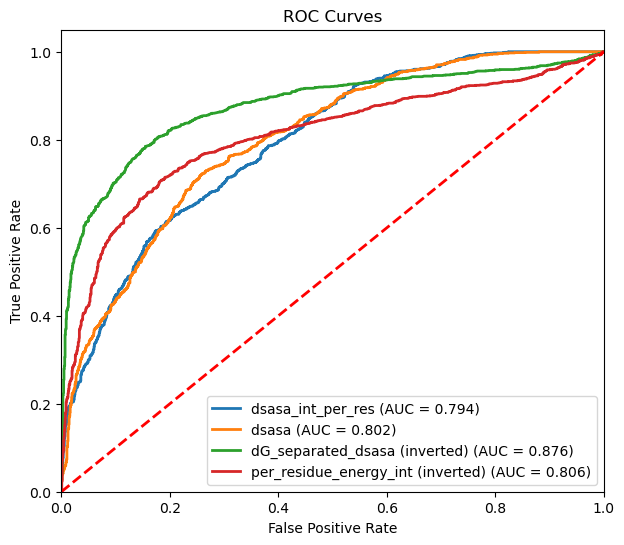

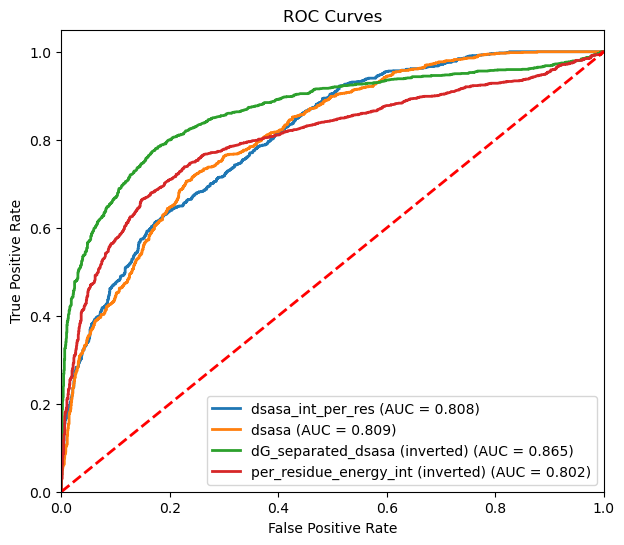

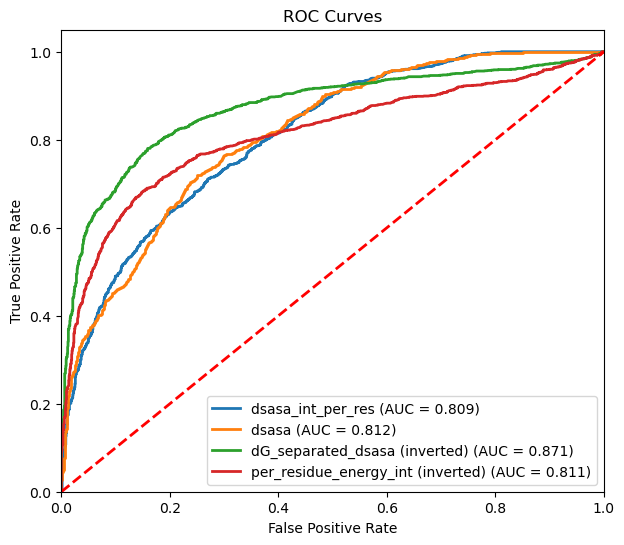

In [4]:
# 绘制ROC曲线，负样本为/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/bin2_decoy_sampled_group1_metrics.csv，正样本为/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/bin2_groundtruth_common_parent_metrics.csv

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 读取数据
groups = [1,2,3]
for group in groups:
    neg_df = pd.read_csv(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/bin2_decoy_sampled_group{group}_metrics.csv')
    pos_df = pd.read_csv(f'/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/bin2_groundtruth_common_parent_metrics.csv')

    # 标签：0=负样本(decoy), 1=正样本(ground truth)
    y_true = [0] * len(neg_df) + [1] * len(pos_df)

    metrics = ['dsasa_int_per_res', 'dsasa', 'dG_separated_dsasa', 'per_residue_energy_int']

    # 这些指标“越负越好”，需反向
    lower_is_better = {'dG_separated_dsasa', 'per_residue_energy_int'}

    plt.figure(figsize=(7, 6))
    for m in metrics:
        scores = neg_df[m].tolist() + pos_df[m].tolist()
        y_scores = [-s for s in scores] if m in lower_is_better else scores

        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        direction_note = " (inverted)" if m in lower_is_better else ""
        plt.plot(fpr, tpr, lw=2, label=f'{m}{direction_note} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc='lower right')
    plt.show()

In [12]:
# =====================
## 子模块1: 数据清洗
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# Config
neg_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/bin2_decoy_common_parent_metrics.csv"
pos_path = "/home/junjiechen/1_work/250401-Dpepalign/Benchmark/Rosetta/interface/Dock/4_GLM/bin2_groundtruth_common_parent_metrics.csv"
features = ["dsasa_int_per_res", "dG_separated_dsasa", "per_residue_energy_int"]
lower_is_better = {"dG_separated_dsasa", "per_residue_energy_int"}

# 训练/评估配置
samples_per_parent_neg = 10
n_splits = 5
n_repeats = 50
base_seed = 20260415


def extract_parent_col(df: pd.DataFrame, pdb_col: str = "PDB") -> pd.DataFrame:
    out = df.copy()
    out["parent_pdb"] = out[pdb_col].astype(str).str[:4]
    return out


def drop_nan_on_features(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    # 将字符串形式的缺失值（如 "Nan"）及其他非数值统一转为 NaN
    out[cols] = out[cols].apply(pd.to_numeric, errors="coerce")
    return out.dropna(subset=cols).copy()


neg_raw = pd.read_csv(neg_path)
pos_raw = pd.read_csv(pos_path)

neg_raw = extract_parent_col(neg_raw)
pos_raw = extract_parent_col(pos_raw)

neg = drop_nan_on_features(neg_raw, features)
pos = drop_nan_on_features(pos_raw, features)

# 仅保留正负样本共同父PDB
common_parents = sorted(set(neg["parent_pdb"]) & set(pos["parent_pdb"]))
neg = neg[neg["parent_pdb"].isin(common_parents)].copy()
pos = pos[pos["parent_pdb"].isin(common_parents)].copy()

print(f"Common parent PDB count: {len(common_parents)}")
print("Negative available samples (after NaN filtering) - head:")
print(neg.groupby("parent_pdb").size().head())
print("Positive available samples (after NaN filtering) - head:")
print(pos.groupby("parent_pdb").size().head())

# 检查不满足40个的pdb
neg_counts = neg.groupby("parent_pdb").size()
insufficient_neg_parents = neg_counts[neg_counts < 40].index.tolist()
print(f"Parents with insufficient negative samples (<40): {insufficient_neg_parents}")

Common parent PDB count: 148
Negative available samples (after NaN filtering) - head:
parent_pdb
1czy    40
1ddv    40
1eg4    40
1f47    40
1f8h    40
dtype: int64
Positive available samples (after NaN filtering) - head:
parent_pdb
1czy    10
1ddv    10
1eg4    10
1f47    10
1f8h    10
dtype: int64
Parents with insufficient negative samples (<40): ['3bqo', '3emh', '4a2a', '4j8b', '5gu4', '5huw', '5lyn']


In [ ]:
# =====================
## 子模块2: 模型训练
# =====================

def build_model() -> Pipeline:
    # GLM (binomial + logit) via logistic regression，利用逻辑回归进行GLM建模
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l2",       # 采用L2正则化，可以实现特定参数的权重为0
                    C=1.0,
                    solver="lbfgs",     # 采用lbfgs算法，即贋牛顿算法
                    max_iter=1000,
                    random_state=base_seed,
                ),
            ),
        ]
    )


def sample_neg_per_parent(
    neg_df: pd.DataFrame,
    parent_col: str,
    n_per_parent: int,
    rng_seed: int,
) -> pd.DataFrame:
    
    rng = np.random.default_rng(rng_seed)       # defalt_rng()是numpy新增的随机数生成器，利用一个随机数种子创建一个随机数生成器实例，确保每次运行时的随机抽样结果可复现
    sampled_parts: list[pd.DataFrame] = []      # 用于存储每个parent_pdb的采样结果

    for _, grp in neg_df.groupby(parent_col, sort=True):
        grp = grp.reset_index(drop=True)
        n = len(grp)
        if n == 0:
            continue
        replace = n < n_per_parent
        idx = rng.choice(n, size=n_per_parent, replace=replace)
        sampled_parts.append(grp.iloc[idx].copy())

    if not sampled_parts:
        raise ValueError("No negative samples available after filtering.")

    return pd.concat(sampled_parts, ignore_index=True)


def model_to_raw_params(model: Pipeline) -> tuple[np.ndarray, float]:
    scaler = model.named_steps["scaler"]
    clf = model.named_steps["clf"]
    scaled_coef = np.asarray(clf.coef_[0], dtype=float)
    scaled_intercept = float(clf.intercept_[0])
    scale = np.asarray(scaler.scale_, dtype=float)
    mean = np.asarray(scaler.mean_, dtype=float)
    raw_weights = scaled_coef / scale
    raw_bias = scaled_intercept - float(np.sum((scaled_coef * mean) / scale))
    return raw_weights, raw_bias


def train_one_repeat(
    neg_df: pd.DataFrame,
    pos_df: pd.DataFrame,
    repeat_seed: int,
    n_splits_cv: int,
) -> dict:
    sampled_neg = sample_neg_per_parent(
        neg_df=neg_df,
        parent_col="parent_pdb",
        n_per_parent=samples_per_parent_neg,
        rng_seed=repeat_seed,
    )

    sampled_neg = sampled_neg.assign(label=0)       # assign方法用于在df中新增一列，这里新增了一个label列，负样本的标签为0
    pos_labeled = pos_df.assign(label=1)
    merged = pd.concat([sampled_neg, pos_labeled], ignore_index=True)       # 默认按照行（axis=0）进行连接，ignore_index=True表示重新索引
    merged = merged.sample(frac=1.0, random_state=repeat_seed).reset_index(drop=True)   # sample方法用于随机打乱数据，frac=1.0表示返回全部数据，random_state确保每次运行时的随机结果可复现，
                                                                                        # reset_index(drop=True)用于重置索引并丢弃原索引

    X = merged[features].copy()
    y = merged["label"].astype(int).to_numpy()
    groups = merged["parent_pdb"].astype(str).to_numpy()

    unique_groups = pd.unique(groups)
    if len(unique_groups) < n_splits_cv:
        raise ValueError(
            f"Unique parent_pdb count ({len(unique_groups)}) is smaller than n_splits ({n_splits_cv})."
        )

    gkf = GroupKFold(n_splits=n_splits_cv)
    glm_oof = np.full(shape=len(merged), fill_value=np.nan, dtype=float)
    fold_raw_weights: list[np.ndarray] = []
    fold_raw_biases: list[float] = []

    for train_idx, test_idx in gkf.split(X, y, groups):     # gkf.split()方法根据groups进行分组划分，确保同一组的样本不会同时出现在训练集和测试集中。这里的同一组代表同一种蛋白-多肽复合物
        model = build_model()
        model.fit(X.iloc[train_idx], y[train_idx])          # fit方法用于训练模型，X.iloc[train_idx]表示训练集的特征数据，y[train_idx]表示训练集的标签数据
        glm_oof[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]

        raw_weights, raw_bias = model_to_raw_params(model)    # 储存每一折的原始权重和偏置，后续会计算平均值
        fold_raw_weights.append(raw_weights)
        fold_raw_biases.append(raw_bias)

    if np.isnan(glm_oof).any():
        raise RuntimeError("GLM OOF prediction contains NaN.")

    metric_oof_scores: dict[str, np.ndarray] = {}
    for m in features:
        raw = merged[m].to_numpy(dtype=float)
        metric_oof_scores[m] = -raw if m in lower_is_better else raw

    mean_raw_weights = np.mean(np.stack(fold_raw_weights, axis=0), axis=0)
    mean_raw_bias = float(np.mean(np.asarray(fold_raw_biases, dtype=float)))

    return {
        "seed": repeat_seed,
        "y": y,
        "groups": groups,
        "glm_oof": glm_oof,
        "metric_oof": metric_oof_scores,
        "raw_weights": mean_raw_weights,
        "raw_bias": mean_raw_bias,
    }


repeat_runs: list[dict] = []
for i in range(n_repeats):
    seed = base_seed + i
    run = train_one_repeat(
        neg_df=neg,
        pos_df=pos,
        repeat_seed=seed,
        n_splits_cv=n_splits,
    )
    repeat_runs.append(run)

    if (i + 1) % 10 == 0 or i == 0:
        glm_auc_now = roc_auc_score(run["y"], run["glm_oof"])
        print(
            f"Repeat {i + 1}/{n_repeats}: GLM AUC={glm_auc_now:.4f}, "
            f"raw_weights={np.round(run['raw_weights'], 6)}, raw_bias={run['raw_bias']:.6f}"
        )

print(f"Training finished. Stored repeats: {len(repeat_runs)}")

Repeat 1/50: GLM AUC=0.9265, raw_weights=[ 0.047429 -2.093218 -0.255568], raw_bias=-10.116753
Repeat 10/50: GLM AUC=0.9241, raw_weights=[ 0.044596 -2.139343 -0.244948], raw_bias=-9.955296
Repeat 20/50: GLM AUC=0.9224, raw_weights=[ 0.044755 -2.052537 -0.233007], raw_bias=-9.755643
Repeat 30/50: GLM AUC=0.9241, raw_weights=[ 0.045757 -2.1276   -0.205011], raw_bias=-9.965393
Repeat 40/50: GLM AUC=0.9209, raw_weights=[ 0.044526 -2.073288 -0.231478], raw_bias=-9.792874
Repeat 50/50: GLM AUC=0.9224, raw_weights=[ 0.044079 -2.134071 -0.233209], raw_bias=-9.899948
Training finished. Stored repeats: 50



AUC summary (mean ± std):
GLM(3 features): 0.9232 ± 0.0022
dsasa_int_per_res: 0.8050 ± 0.0040
dG_separated_dsasa (inverted): 0.8714 ± 0.0029
per_residue_energy_int (inverted): 0.8077 ± 0.0027


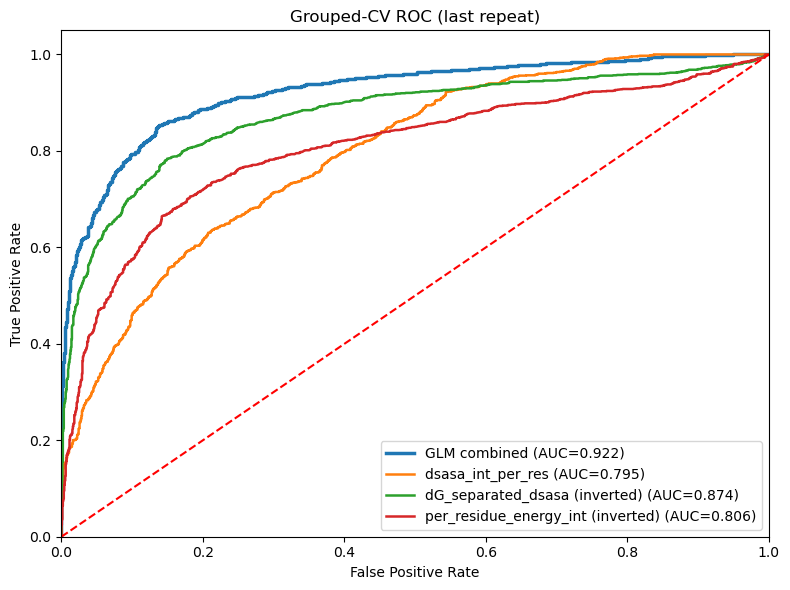

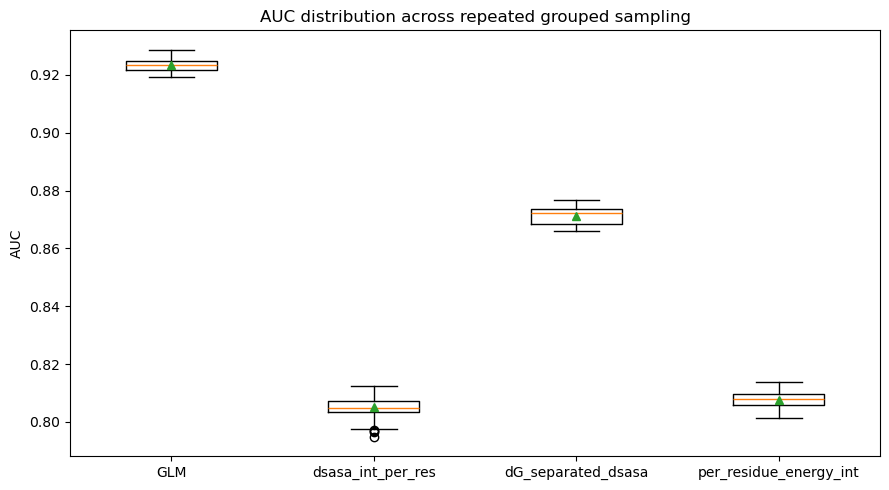

In [20]:
# =====================
## 子模块3: 验证与可视化
# =====================

def mean_std(x: list[float]) -> tuple[float, float]:
    arr = np.array(x, dtype=float)
    return float(arr.mean()), float(arr.std(ddof=1))


all_glm_auc = []
all_metric_auc = {m: [] for m in features}

for run in repeat_runs:
    y = run["y"]
    glm_oof = run["glm_oof"]
    metric_oof = run["metric_oof"]

    all_glm_auc.append(roc_auc_score(y, glm_oof))
    for m in features:
        all_metric_auc[m].append(roc_auc_score(y, metric_oof[m]))

glm_mean, glm_std = mean_std(all_glm_auc)
print("\nAUC summary (mean ± std):")
print(f"GLM(3 features): {glm_mean:.4f} ± {glm_std:.4f}")
for m in features:
    mm, ss = mean_std(all_metric_auc[m])
    direction_note = " (inverted)" if m in lower_is_better else ""
    print(f"{m}{direction_note}: {mm:.4f} ± {ss:.4f}")

# 使用最后一轮展示ROC
last_run = repeat_runs[-1]
last_y = last_run["y"]
last_glm_oof = last_run["glm_oof"]
last_metric_oof = last_run["metric_oof"]

plt.figure(figsize=(8, 6))
fpr_glm, tpr_glm, _ = roc_curve(last_y, last_glm_oof)
plt.plot(fpr_glm, tpr_glm, lw=2.5, label=f"GLM combined (AUC={roc_auc_score(last_y, last_glm_oof):.3f})")

for m in features:
    fpr_m, tpr_m, _ = roc_curve(last_y, last_metric_oof[m])
    note = " (inverted)" if m in lower_is_better else ""
    auc_m = roc_auc_score(last_y, last_metric_oof[m])
    plt.plot(fpr_m, tpr_m, lw=1.8, label=f"{m}{note} (AUC={auc_m:.3f})")

plt.plot([0, 1], [0, 1], "r--", lw=1.5)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Grouped-CV ROC (last repeat)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 跨重复轮次的AUC分布
plot_data = [all_glm_auc] + [all_metric_auc[m] for m in features]
plot_labels = ["GLM"] + features

plt.figure(figsize=(9, 5))
plt.boxplot(plot_data, tick_labels=plot_labels, showmeans=True)
plt.ylabel("AUC")
plt.title("AUC distribution across repeated grouped sampling")
plt.tight_layout()
plt.show()

In [21]:
# =====================
## 子模块4: 平均权重与实际应用
# =====================

raw_weight_matrix = np.stack([run["raw_weights"] for run in repeat_runs], axis=0)
raw_bias_vector = np.asarray([run["raw_bias"] for run in repeat_runs], dtype=float)

mean_raw_weights = raw_weight_matrix.mean(axis=0)
std_raw_weights = raw_weight_matrix.std(axis=0, ddof=1)
mean_raw_bias = float(raw_bias_vector.mean())
std_raw_bias = float(raw_bias_vector.std(ddof=1))

glm_param_summary = pd.DataFrame(
    {
        "feature": features + ["bias"],
        "mean": list(mean_raw_weights) + [mean_raw_bias],
        "std": list(std_raw_weights) + [std_raw_bias],
    }
 )

print("Average GLM parameters in raw feature space:")
print(glm_param_summary.to_string(index=False))
print()
print("Decision rule:")
print(
    "logit = bias + w1 * dsasa_int_per_res + w2 * dG_separated_dsasa + "
    "w3 * per_residue_energy_int"
 )
print("probability = 1 / (1 + exp(-logit))")
print("predict positive if probability >= 0.5, otherwise predict negative")


def glm_logit_from_metrics(
    dsasa_int_per_res: float,
    dG_separated_dsasa: float,
    per_residue_energy_int: float,
) -> float:
    x = np.array(
        [dsasa_int_per_res, dG_separated_dsasa, per_residue_energy_int],
        dtype=float,
    )
    return float(mean_raw_bias + np.dot(mean_raw_weights, x))


def glm_probability_from_metrics(
    dsasa_int_per_res: float,
    dG_separated_dsasa: float,
    per_residue_energy_int: float,
) -> float:
    logit = glm_logit_from_metrics(
        dsasa_int_per_res=dsasa_int_per_res,
        dG_separated_dsasa=dG_separated_dsasa,
        per_residue_energy_int=per_residue_energy_int,
    )
    return float(1.0 / (1.0 + np.exp(-logit)))


def glm_predict_label_from_metrics(
    dsasa_int_per_res: float,
    dG_separated_dsasa: float,
    per_residue_energy_int: float,
) -> int:
    probability = glm_probability_from_metrics(
        dsasa_int_per_res=dsasa_int_per_res,
        dG_separated_dsasa=dG_separated_dsasa,
        per_residue_energy_int=per_residue_energy_int,
    )
    return int(probability >= 0.5)


example_row = pos.iloc[0][features]
example_logit = glm_logit_from_metrics(
    dsasa_int_per_res=float(example_row["dsasa_int_per_res"]),
    dG_separated_dsasa=float(example_row["dG_separated_dsasa"]),
    per_residue_energy_int=float(example_row["per_residue_energy_int"]),
 )
example_probability = glm_probability_from_metrics(
    dsasa_int_per_res=float(example_row["dsasa_int_per_res"]),
    dG_separated_dsasa=float(example_row["dG_separated_dsasa"]),
    per_residue_energy_int=float(example_row["per_residue_energy_int"]),
 )
example_label = glm_predict_label_from_metrics(
    dsasa_int_per_res=float(example_row["dsasa_int_per_res"]),
    dG_separated_dsasa=float(example_row["dG_separated_dsasa"]),
    per_residue_energy_int=float(example_row["per_residue_energy_int"]),
 )

print()
print("Example using one positive sample:")
print(f"logit = {example_logit:.6f}")
print(f"probability = {example_probability:.6f}")
print(f"predicted label = {example_label} (1=positive, 0=negative)")

Average GLM parameters in raw feature space:
               feature      mean      std
     dsasa_int_per_res  0.044575 0.001313
    dG_separated_dsasa -2.118124 0.052927
per_residue_energy_int -0.228708 0.016294
                  bias -9.879178 0.189561

Decision rule:
logit = bias + w1 * dsasa_int_per_res + w2 * dG_separated_dsasa + w3 * per_residue_energy_int
probability = 1 / (1 + exp(-logit))
predict positive if probability >= 0.5, otherwise predict negative

Example using one positive sample:
logit = 4.024436
probability = 0.982440
predicted label = 1 (1=positive, 0=negative)


In [ ]:
"""
GLM = 0.044575 * dSASA_int_per_res + (-2.118124) * dG_separated/dSASAx100 + (-0.228708) * energy_per_intres - 9.879178
probablity = 1 / (1 + exp(-GLM))
"""